In [2]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

## Check SCRFs

In [8]:
ls ../data/scrf_extraction/600Hz_20241227-Lnative-N10

losses_scrf_61.pt  opti.npy  scrf_61.pt  total.csv  total.npy


In [9]:
new_scrf = torch.load("../data/scrf_extraction/600Hz_20241227-Lnative-N10/scrf_61.pt")
old_scrf = torch.load("../data/scrf_81_600MHz.pt")
new_scrf.shape, old_scrf.shape

/tmp/ipykernel_1825080/1208142829.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_scrf = torch.load("../data/scrf_extraction/600Hz_20241227-Lnative-N10/scrf_61.pt")


(torch.Size([10, 1, 1, 1, 1, 81]), torch.Size([17161, 1, 1, 1, 1, 81]))

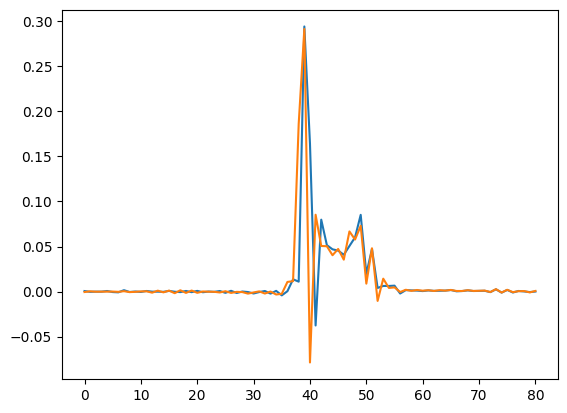

In [10]:
idx = 4
plt.plot(new_scrf[idx].squeeze())
plt.plot(old_scrf[idx].squeeze())

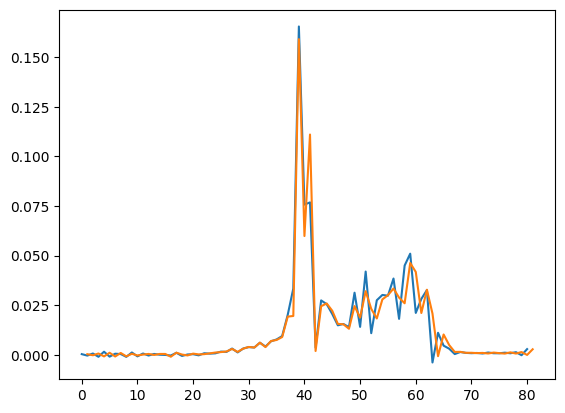

In [13]:
idx = 9
plt.plot(np.arange(0,81),new_scrf[idx].squeeze())
plt.plot(np.arange(0,81)+1, old_scrf[idx].squeeze())

## Filter SRCFs

In [ ]:
df = pd.read_csv("../data/600Hz_20241227-Lnative/fids.csv")
df

,fid_name,z1,z2
0,lshp_z1_-5929_z2_1992.fid,-5929,1992
1,lshp_z1_-5877_z2_2106.fid,-5877,2106
2,lshp_z1_-5983_z2_2164.fid,-5983,2164
3,lshp_z1_-5911_z2_2042.fid,-5911,2042
4,lshp_z1_-5901_z2_2032.fid,-5901,2032
...,...,...,...
17156,lshp_z1_-5827_z2_2038.fid,-5827,2038
17157,lshp_z1_-5973_z2_2058.fid,-5973,2058
17158,lshp_z1_-5901_z2_2190.fid,-5901,2190
17159,lshp_z1_-5853_z2_2234.fid,-5853,2234


In [ ]:
scrf = torch.load("../data/scrf_81_600MHz.pt")
assert scrf.shape[0] == len(df)
scrf.shape

/tmp/ipykernel_1646263/1177895323.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  scrf = torch.load("/scratch/mbuk/nmr/projects/01_shimator/shimnet/data/scrf_81_600MHz.p

torch.Size([17161, 1, 1, 1, 1, 81])

In [69]:
z2_min = 2058
z2_max = 2178
fileter_name = f"z2_{z2_min}_to_{z2_max}"

filter_bool = (df["z2"] >= z2_min) & (df["z2"] <= z2_max).to_numpy()

torch.save(scrf[filter_bool], f"scrf_81_600MHz-filtered-{fileter_name}.pt")
df.loc[filter_bool].to_csv(f"fids_600MHz_filtered-{fileter_name}.csv", index=False)

In [ ]:
# def extract_z1_z2(fid_name):
#     fid_name = fid_name[:-4]  # Remove file extension
#     parts = fid_name.split('_')
#     z1 = int(parts[2])  # Extract number after 'Z'
#     z2 = int(parts[-1])  # Extract number after 'Z'
#     return z1, z2

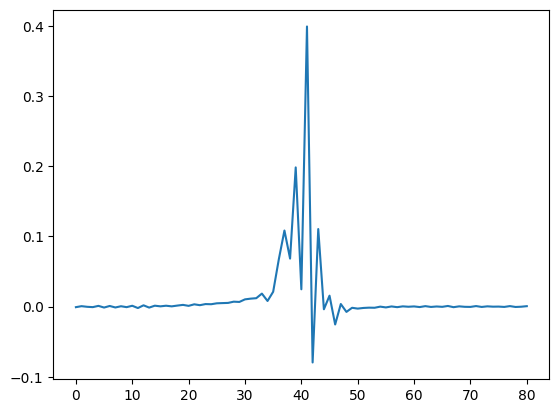

In [73]:
idx = 3
plt.plot(scrf[filter_bool][idx].squeeze())

## Smooth SRCFs

Text(0.5, 0, 'frquency points')

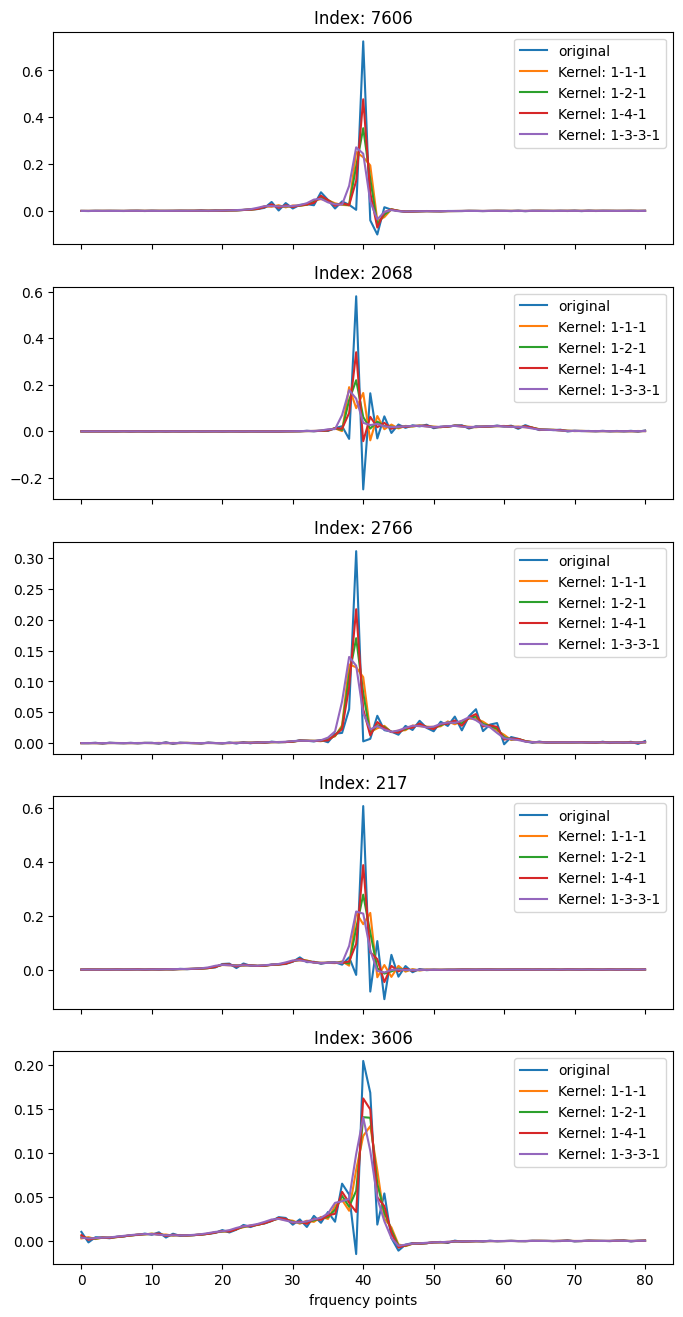

In [104]:
output_dir = Path("../data/smoothed_scrf_kernels")
output_dir.mkdir(parents=True, exist_ok=True)
kernels = {
    "1-1-1": torch.ones((1, 1, 3)) / 3,
    "1-2-1": torch.tensor([0.25, 0.5, 0.25]).view(1, 1, 3),
    "1-4-1": torch.tensor([1/6, 4/6, 1/6]).view(1, 1, 3),
    "1-3-3-1": torch.tensor([1/8, 3/8, 3/8, 1/8]).view(1, 1, 4),
}

indices_to_plot = np.random.choice(scrf.shape[0], size=5, replace=False)
fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(8, 16), sharex=True)

for i, idx in enumerate(indices_to_plot):
    axs[i].plot(scrf[idx,0,0,0,0].squeeze(), label="original")
    axs[i].legend()
    axs[i].set_title(f"Index: {idx}")
for kernel_name, kernel in kernels.items():
    smoothed = torch.conv1d(scrf[:,0,0,0,0].unsqueeze(1), weight=kernel, padding="same")
    torch.save(smoothed, output_dir / f"scrf_81_600MHz_smoothed_{kernel_name}.pt")
    for i, idx in enumerate(indices_to_plot):
        axs[i].plot(smoothed[idx].squeeze(), label=f"Kernel: {kernel_name}")
        axs[i].legend()
        axs[i].set_title(f"Index: {idx}")
        
axs[-1].set_xlabel("frquency points")

## Filter smoothed

In [1]:
filter_bool

NameError: name 'filter_bool' is not defined